In [1]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

In [2]:
!pip install lightning torchinfo -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.5/828.5 kB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 62.2 MB/s eta 0:00:00


# 실습 2 : VGG Model Fine Tuning + ImageGenerator

## Import Module

In [3]:
import torch
from torch import nn
from torch.nn import functional as F
from torchmetrics import functional as FM
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
from torchinfo import summary

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import numpy as np
import pandas as pd

from PIL import Image
from IPython import display

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

device ='cuda:0'
torch.__version__,L.__version__
# ('2.6.0+cu124', '2.5.1.post0') 2505
# ('2.8.0+cu126', '2.5.5')  2510

('2.8.0+cu126', '2.5.5')

## **Dataset Load**

In [4]:
from torchvision.datasets.utils import download_and_extract_archive
import pathlib
dataset_url = \
      "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
root = './'
data_dir='Dataset'
download_and_extract_archive(dataset_url, root, data_dir)
data_dir = root+data_dir+'/flower_photos'
data_dir

100%|██████████| 229M/229M [00:11<00:00, 20.2MB/s]


'./Dataset/flower_photos'

In [5]:
!ls {data_dir}

daisy  dandelion  LICENSE.txt  roses  sunflowers  tulips


### Train / Test Data split

In [6]:
!pip install split-folders

In [7]:
import splitfolders
sp_path="flower_photos_sp"
splitfolders.ratio(data_dir, output=sp_path,
    seed=1337, ratio=(.7, .3), group_prefix=None, move=True )
sp_train = pathlib.Path(sp_path+'/train')
sp_test = pathlib.Path(sp_path+'/val')
sp_train

Copying files: 3670 files [00:00, 24059.98 files/s]


PosixPath('flower_photos_sp/train')

### Check Images

In [8]:
# 지정 폴더 아래에 있는 모든 *.jpg 파일의 수
#  및 폴더명 목록을 리턴
def check_dir(d_path):
    img_count = len(list(d_path.glob('*/*.jpg')))
    c_name = np.array([item.name for item in d_path.glob('*') if item.name != "LICENSE.txt"])
    return img_count, c_name, len(c_name)

# check_dir()로 폴더명과 이미지 숫자 확인
image_count, CLASS_train, class_num = check_dir(sp_train)
CLASS_train.sort()
print('Train image_count: {}\nclasses: {}'.format(image_count, CLASS_train))
image_count, CLASS_test, class_num = check_dir(sp_test)
CLASS_test.sort()
print('Test image_count: {}\nclasses: {}'.format(image_count, CLASS_test))

Train image_count: 2567
classes: ['daisy' 'dandelion' 'roses' 'sunflowers' 'tulips']
Test image_count: 1103
classes: ['daisy' 'dandelion' 'roses' 'sunflowers' 'tulips']


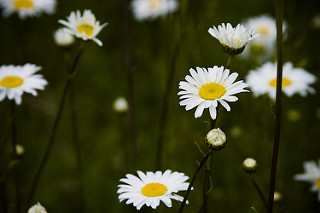

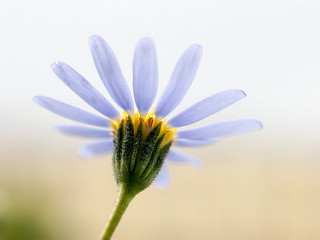

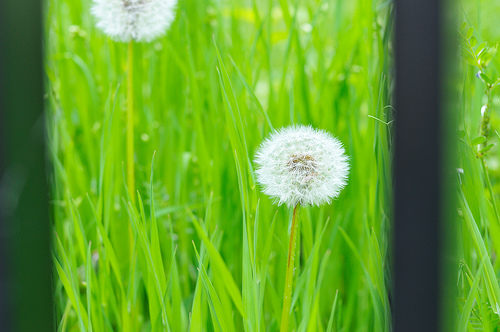

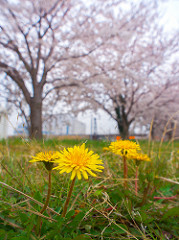

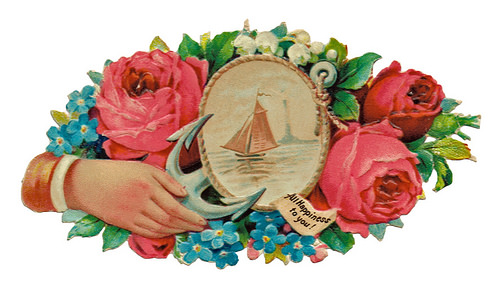

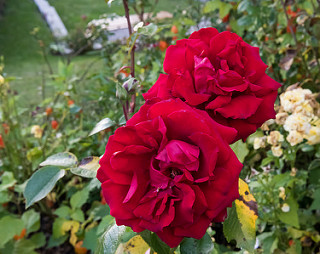

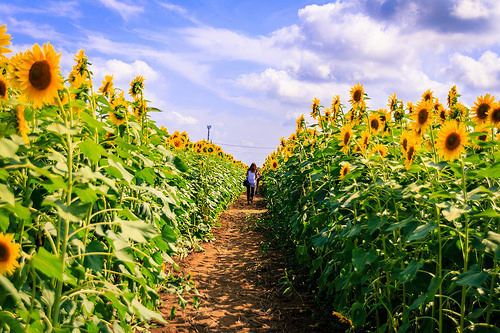

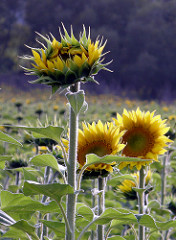

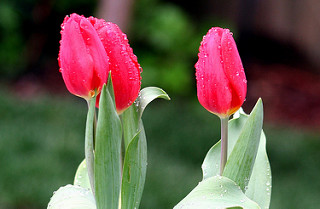

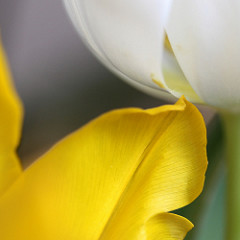

In [9]:
# 지정 path 아래에 있는 폴더에서 이미지 두장씩을 확인
def check_image(d_path, class_list):
    for i in range(len(class_list)):
        class_temp = list(d_path.glob(str(class_list[i])+'/*'))
        for image_path in class_temp[:2]:
            display.display(Image.open(str(image_path)))
# check_image()로 이미지 두장씩 확인
check_image(sp_train, CLASS_train)

### ImageFolder API  

In [10]:
# Imagae size 결정 **
IN_IMG_SIZE = 224 ## 112
batch_n = 32

In [11]:
from torchvision.datasets import ImageFolder

## loader에 적용할 transform
train_transforms = v2.Compose([
    v2.Resize((IN_IMG_SIZE, IN_IMG_SIZE)),
#    v2.RandomAffine(degrees=15, translate=(0.2, 0.2), shear=0.2),
    v2.RandomResizedCrop(IN_IMG_SIZE, scale=[0.8, 1.2], ratio=[0.75,1.33],antialias=True ),
#    v2.RandomHorizontalFlip(0.5),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True) ] )

test_transforms = v2.Compose([
    v2.Resize((IN_IMG_SIZE, IN_IMG_SIZE)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True) ] )

train_imgs = ImageFolder(sp_train, transform=train_transforms) #(image,label)
test_imgs = ImageFolder(sp_test, transform=test_transforms)
train_loader = DataLoader(train_imgs, batch_size=batch_n, shuffle=True,num_workers=4)
test_loader = DataLoader(test_imgs, batch_size=batch_n, shuffle=False,num_workers=4)

len(train_imgs),len(test_imgs)

(2567, 1103)

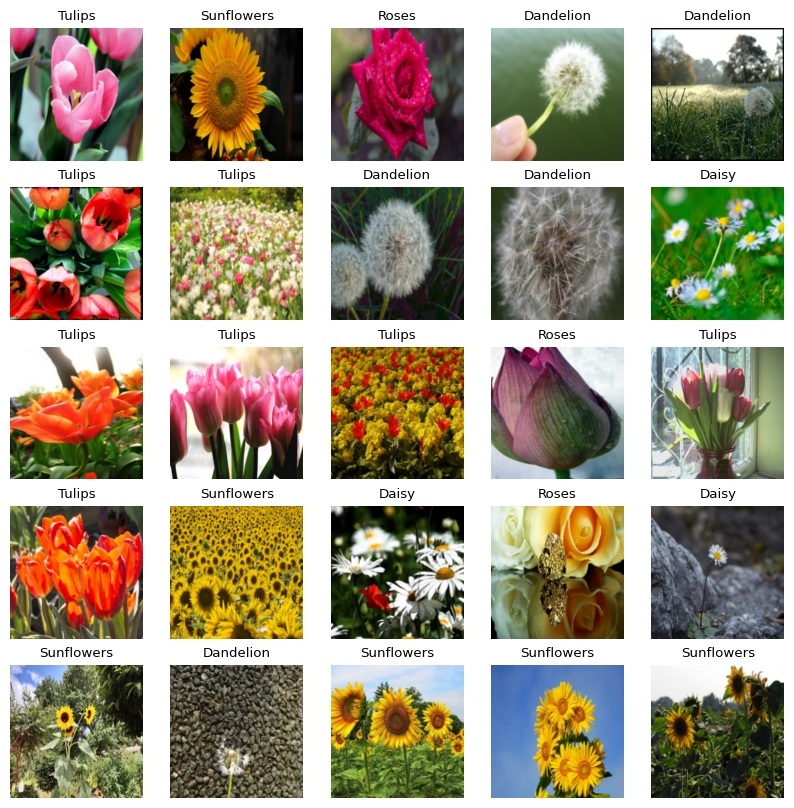

In [12]:
def show_batch(data_gen, class_l):
    # get image and label from data generator
    img_batch, l_batch = next(iter(data_gen))
    plt.figure(figsize=(10,10))
    for n in range(25):
        ax = plt.subplot(5,5,n+1)
        plt.imshow(img_batch[n].permute(1, 2, 0))
        plt.title(class_l[l_batch[n]].title())
        plt.axis('off')
    return img_batch, l_batch

# check dataset
_,_ = show_batch(train_loader, CLASS_train)

## **Load VGG16 model**

In [13]:
import torchvision
vgg16 = torchvision.models.vgg16(pretrained=True)
model_vgg = vgg16.features
summary(model_vgg, input_size=(batch_n, 3, IN_IMG_SIZE, IN_IMG_SIZE))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 158MB/s]


Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [32, 512, 7, 7]           --
├─Conv2d: 1-1                            [32, 64, 224, 224]        1,792
├─ReLU: 1-2                              [32, 64, 224, 224]        --
├─Conv2d: 1-3                            [32, 64, 224, 224]        36,928
├─ReLU: 1-4                              [32, 64, 224, 224]        --
├─MaxPool2d: 1-5                         [32, 64, 112, 112]        --
├─Conv2d: 1-6                            [32, 128, 112, 112]       73,856
├─ReLU: 1-7                              [32, 128, 112, 112]       --
├─Conv2d: 1-8                            [32, 128, 112, 112]       147,584
├─ReLU: 1-9                              [32, 128, 112, 112]       --
├─MaxPool2d: 1-10                        [32, 128, 56, 56]         --
├─Conv2d: 1-11                           [32, 256, 56, 56]         295,168
├─ReLU: 1-12                             [32, 256, 56, 56]      

### 일부 Layer Freeze
**마지막 `conv block`만 남기고 나머지는 전부 freeze**
- 마지막 conv block이 fine tuning 됨

In [14]:
vgg16_f = vgg16.features
for i, child in enumerate(vgg16_f.children()):
  if i < len(vgg16_f) - 7: ## 수정 point ##
    for param in child.parameters():
      param.requires_grad = False
  else :
    print(f"Trainable:[{i}]",child)

Trainable:[24] Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Trainable:[25] ReLU(inplace=True)
Trainable:[26] Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Trainable:[27] ReLU(inplace=True)
Trainable:[28] Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Trainable:[29] ReLU(inplace=True)
Trainable:[30] MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)


In [15]:
for child in vgg16_f.children():
    for param in child.parameters():
        print(param.requires_grad,":",child, param.size())
        #break

False : Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) torch.Size([64, 3, 3, 3])
False : Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) torch.Size([64])
False : Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) torch.Size([64, 64, 3, 3])
False : Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) torch.Size([64])
False : Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) torch.Size([128, 64, 3, 3])
False : Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) torch.Size([128])
False : Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) torch.Size([128, 128, 3, 3])
False : Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) torch.Size([128])
False : Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) torch.Size([256, 128, 3, 3])
False : Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) torch.Size([256])
False : Conv2d(256, 256, 

In [16]:
summary(vgg16_f, input_size=(batch_n, 3, IN_IMG_SIZE, IN_IMG_SIZE))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [32, 512, 7, 7]           --
├─Conv2d: 1-1                            [32, 64, 224, 224]        (1,792)
├─ReLU: 1-2                              [32, 64, 224, 224]        --
├─Conv2d: 1-3                            [32, 64, 224, 224]        (36,928)
├─ReLU: 1-4                              [32, 64, 224, 224]        --
├─MaxPool2d: 1-5                         [32, 64, 112, 112]        --
├─Conv2d: 1-6                            [32, 128, 112, 112]       (73,856)
├─ReLU: 1-7                              [32, 128, 112, 112]       --
├─Conv2d: 1-8                            [32, 128, 112, 112]       (147,584)
├─ReLU: 1-9                              [32, 128, 112, 112]       --
├─MaxPool2d: 1-10                        [32, 128, 56, 56]         --
├─Conv2d: 1-11                           [32, 256, 56, 56]         (295,168)
├─ReLU: 1-12                             [32, 256, 56,

### Customize Layer 추가
- ***batch normalizatin을 필히 사용할 것***

In [17]:
###
lr=0.0001

class VGGFineTune2(L.LightningModule):
    def __init__(self, vggnet, num_classes):
        super(VGGFineTune2, self).__init__()
        self.features = vggnet
        self.linear = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512*7*7,512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes) )

    def forward(self, x):
        x = self.features(x)
        x = self.linear(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)
        acc = FM.accuracy(y_pred, y, task='multiclass', num_classes=5)
        metrics={'loss':loss, 'acc':acc}
        self.log_dict(metrics,prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)
        acc = FM.accuracy(y_pred, y, task='multiclass', num_classes=5)
        metrics = {'val_loss':loss, 'val_acc':acc}
        self.log_dict(metrics,prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=lr)

vggFineTune2 = VGGFineTune2(vgg16_f, class_num)
summary(vggFineTune2, input_size=(batch_n, 3, IN_IMG_SIZE, IN_IMG_SIZE))

Layer (type:depth-idx)                   Output Shape              Param #
VGGFineTune2                             [32, 5]                   --
├─Sequential: 1-1                        [32, 512, 7, 7]           --
│    └─Conv2d: 2-1                       [32, 64, 224, 224]        (1,792)
│    └─ReLU: 2-2                         [32, 64, 224, 224]        --
│    └─Conv2d: 2-3                       [32, 64, 224, 224]        (36,928)
│    └─ReLU: 2-4                         [32, 64, 224, 224]        --
│    └─MaxPool2d: 2-5                    [32, 64, 112, 112]        --
│    └─Conv2d: 2-6                       [32, 128, 112, 112]       (73,856)
│    └─ReLU: 2-7                         [32, 128, 112, 112]       --
│    └─Conv2d: 2-8                       [32, 128, 112, 112]       (147,584)
│    └─ReLU: 2-9                         [32, 128, 112, 112]       --
│    └─MaxPool2d: 2-10                   [32, 128, 56, 56]         --
│    └─Conv2d: 2-11                      [32, 256, 56, 56]   

## **Fit**

In [18]:
%%time
vggFineTune2 = VGGFineTune2(vgg16_f, class_num)
model_name = "VGGNetFineTune_2"
epochs=5 #15
logger = CSVLogger("logs", name=model_name)
trainer = Trainer(max_epochs=epochs, logger=logger,)
#                  limit_train_batches=0.5, limit_val_batches=0.5 )
trainer.fit(vggFineTune2, train_loader, val_dataloaders=test_loader)
# Wall time: 1min 44s @ 5epoch

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name     | Type     

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=5` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


CPU times: user 1min 33s, sys: 5.29 s, total: 1min 39s
Wall time: 1min 42s


## **Analysis**

In [19]:
v_num = logger.version
history = pd.read_csv(f'./logs/{model_name}/version_{v_num}/metrics.csv')

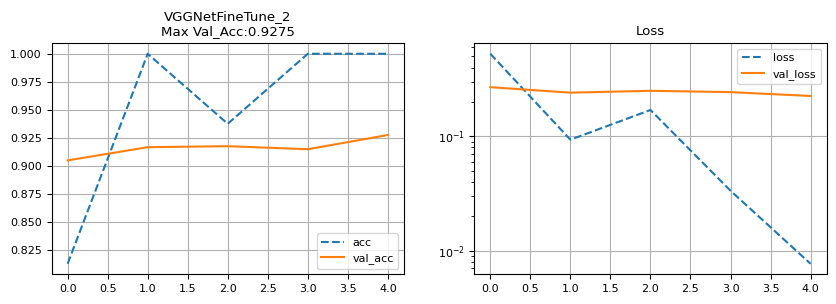

In [20]:
h1 = history.drop('step', axis=1).groupby('epoch').last()
max_ = h1['val_acc'].max()

plt.figure(figsize=(10,3))
title = model_name
plt.subplot(121)
plt.title(f"{title}\nMax Val_Acc:{max_:.4f}")
plt.plot(h1['acc'],'--', label='acc')
plt.plot(h1['val_acc'], label='val_acc')
#plt.ylim(0.7, 1)
plt.legend()
plt.grid()

plt.subplot(122)
plt.title("Loss")
plt.plot(h1['loss'],'--', label='loss')
plt.plot(h1['val_loss'], label='val_loss')
plt.semilogy()
plt.legend()
plt.grid()
plt.show()

**with Augmentation**

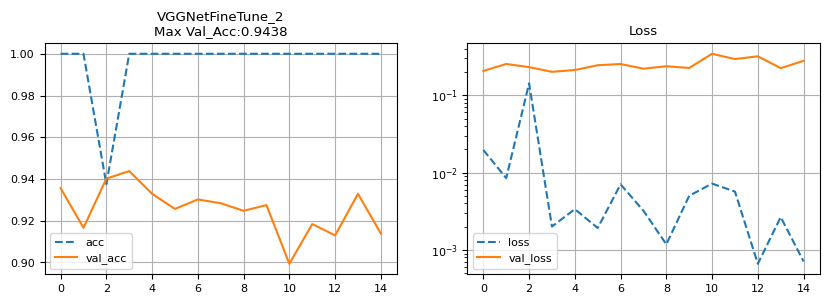

**w/o Augmentation**

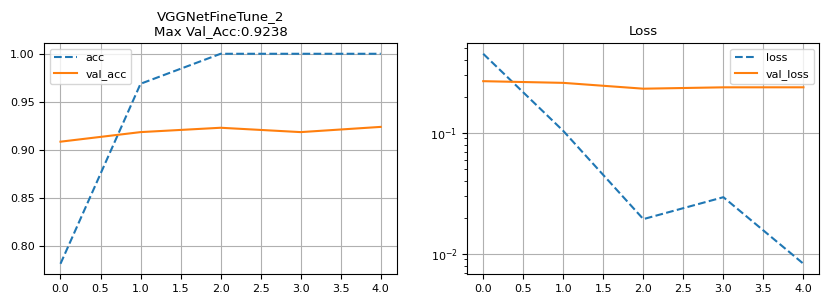

**ResNet26 결과**

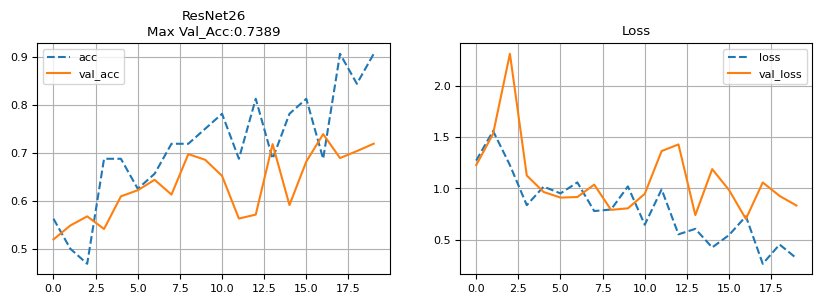

**GoogleNet 결과**

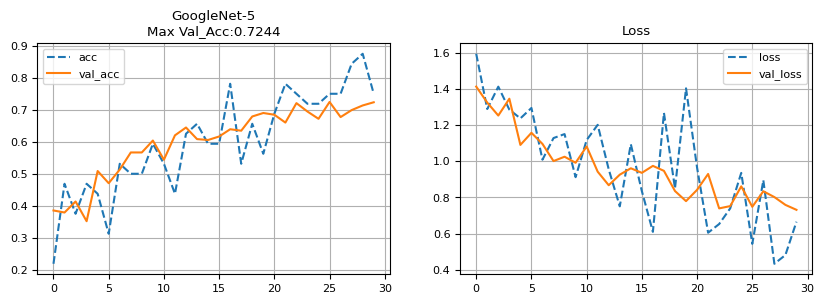

## **Prediction result with test image**

In [21]:
n_plot = 10
np.random.randint(0,len(test_imgs),n_plot)

array([304, 399, 710, 557, 391, 278, 798, 504, 822, 276])

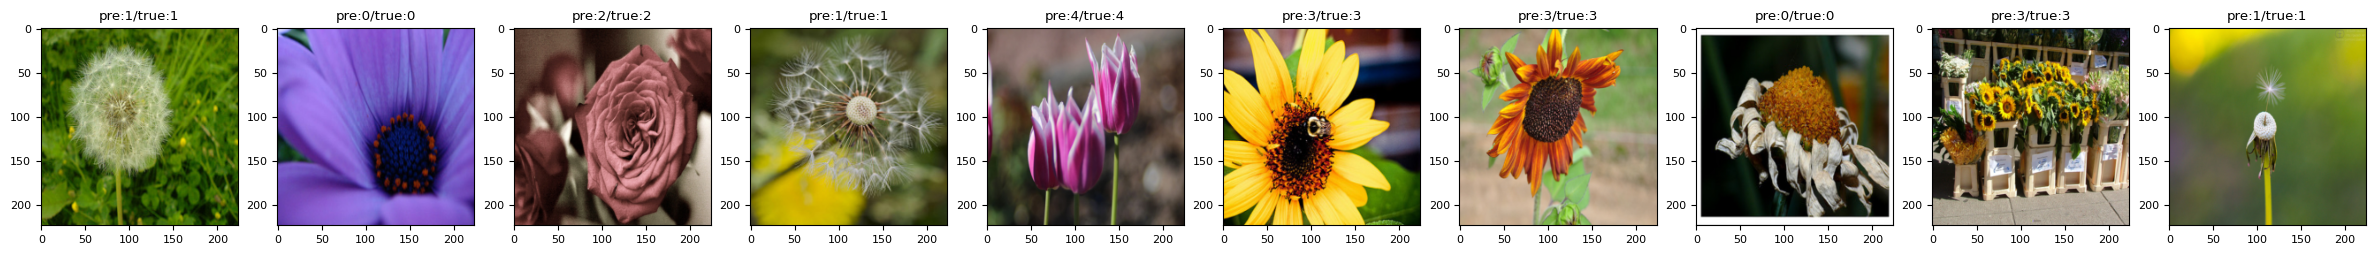

In [22]:
n_plot = 10
idx = np.random.randint(0,len(test_imgs),n_plot)

plt.figure(figsize=(3*n_plot, n_plot))
vggFineTune2.eval()
for i,img_idx in enumerate(idx):
    predict = vggFineTune2(test_imgs[img_idx][0].unsqueeze(dim=0)).cpu().detach().numpy()
    img = test_imgs[img_idx][0].permute(1, 2, 0)
    plt.subplot(1,n_plot,i+1)
    plt.imshow(img, cmap='gray')
    plt.title('pre:{}/true:{}'.format(np.argmax(predict),test_imgs[img_idx][1]))
plt.show()

# **실습과제**

**성능개선을 위한 접근 방법을 생각해 보자**  
-- 모델의 크기는 적당한가?  
-- Freeze하는 레이어는 적당한가?  
-- 추가 layer의 수준과 방법은 어떻게 개선할 수 있을까?  
== 추가 layer에 average pooling을 사용, 모델의 크기를 줄여 보자  
== DataAugmentaion을 적용해 보자  

### 과제 1
- 마지막 Conv Layer만 남기고 Freeze  
- AvgPool2D Layer 사용   
      nn.AvgPool2d(kernel_size,stride)  
- 추가할 layer의 크기를 결정하자.

### 과제 2
- 모든 Layer를 Freeze한 경우와, Trainalble한 경우를 비교해 보자  


### 과제 3
- Augmentation을 적용해 보자. epoch를 10으로 늘리고, 성능을 검토하자  

In [ ]:
from torchvision.datasets import ImageFolder

## loader에 적용할 transform
train_transforms = v2.Compose([
    v2.Resize((IN_IMG_SIZE, IN_IMG_SIZE)),
    v2.RandomAffine(degrees=15, translate=(0.2, 0.2), shear=0.2),
    v2.RandomResizedCrop(IN_IMG_SIZE, scale=[0.8, 1.2], ratio=[0.75,1.33],antialias=True ),
    v2.RandomHorizontalFlip(0.5),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True) ] )

test_transforms = v2.Compose([
    v2.Resize((IN_IMG_SIZE, IN_IMG_SIZE)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True) ] )

train_imgs = ImageFolder(sp_train, transform=train_transforms) #(image,label)
test_imgs = ImageFolder(sp_test, transform=test_transforms)
train_loader = DataLoader(train_imgs, batch_size=batch_n, shuffle=True,num_workers=4)
test_loader = DataLoader(test_imgs, batch_size=batch_n, shuffle=False,num_workers=4)